# Uncertainty-Aware Transformer for BIST 100 Log Return Forecasting

**Project:** Uncertainty-Aware Financial Forecasting (COM0415 Applied Deep Learning)  
**Authors:** Lara Yıldırım, Belkıs Derin Yüksel

**Purpose:** Final-submission model. Encoder-only Transformer with Monte Carlo Dropout for
epistemic uncertainty quantification. Predicts next-day BIST 100 log return.

**Features (D=5):** BIST100 Close, S&P500 Close, CPI (CPIAUCSL), Federal Funds Rate (FEDFUNDS), Industrial Production (INDPRO)  
**Target:** $r_{t+1} = \ln(P_{t+1}/P_t)$ where $P$ is BIST 100 Close  
**Split:** Chronological (Train: 2010–2022, Val: 2023, Test: 2024–2026-04)  
**Metrics:** MAE, RMSE, Directional Accuracy + comparison vs LSTM baseline and Naive ($\hat{r}=0$)

## Step 1: Install and Import Libraries

In [1]:
!pip install torch pandas numpy scikit-learn matplotlib --quiet

import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch: {torch.__version__}')

Using device: cuda
PyTorch: 2.10.0+cu128


## Step 2: Load Cleaned Dataset


In [2]:
from google.colab import files
uploaded = files.upload()  # Upload financial_data.csv

df = pd.read_csv(list(uploaded.keys())[0], index_col=0, parse_dates=True)
df = df.sort_index()

FEATURES = ['BIST100_Close', 'SP500_Close', 'CPIAUCSL', 'FEDFUNDS', 'INDPRO']
missing = [f for f in FEATURES if f not in df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')
df = df[FEATURES].dropna()

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
df.head()

Saving financial_data.csv to financial_data.csv
Dataset shape: (4231, 5)
Date range: 2010-01-04 to 2026-04-23


,BIST100_Close,SP500_Close,CPIAUCSL,FEDFUNDS,INDPRO
Date,,,,,
2010-01-04,533.679199,1132.989990,217.488,0.11,89.3426
2010-01-05,541.148132,1136.520020,217.488,0.11,89.3426
2010-01-06,545.471130,1137.140015,217.488,0.11,89.3426
2010-01-07,549.726074,1141.689941,217.488,0.11,89.3426
2010-01-08,547.976074,1144.979980,217.488,0.11,89.3426


## Step 3: Construct Target & Chronological Split

In [3]:
df['log_return_next'] = np.log(df['BIST100_Close'].shift(-1) / df['BIST100_Close'])
df = df.dropna()

TRAIN_END = '2022-12-31'
VAL_END   = '2023-12-31'

train_df = df.loc[:TRAIN_END]
val_df   = df.loc[(df.index > TRAIN_END) & (df.index <= VAL_END)]
test_df  = df.loc[df.index > VAL_END]

print(f'Train: {train_df.index.min().date()} to {train_df.index.max().date()}  ({len(train_df)} rows)')
print(f'Val:   {val_df.index.min().date()} to {val_df.index.max().date()}  ({len(val_df)} rows)')
print(f'Test:  {test_df.index.min().date()} to {test_df.index.max().date()}  ({len(test_df)} rows)')

Train: 2010-01-04 to 2022-12-30  (3374 rows)
Val:   2023-01-02 to 2023-12-29  (259 rows)
Test:  2024-01-02 to 2026-04-22  (597 rows)


## Step 4: Feature Scaling (Fit on Train Only)

In [4]:
scaler = StandardScaler()
scaler.fit(train_df[FEATURES].values)

X_train = scaler.transform(train_df[FEATURES].values).astype(np.float32)
X_val   = scaler.transform(val_df[FEATURES].values).astype(np.float32)
X_test  = scaler.transform(test_df[FEATURES].values).astype(np.float32)

y_train = train_df['log_return_next'].values.astype(np.float32)
y_val   = val_df['log_return_next'].values.astype(np.float32)
y_test  = test_df['log_return_next'].values.astype(np.float32)

print('Scaling OK — train mean (should be ~0):', X_train.mean(axis=0).round(3))

Scaling OK — train mean (should be ~0): [-0. -0.  0.  0.  0.]


## Step 5: Sliding Windows (T = 30)

In [5]:
LOOKBACK = 30

def make_windows(X, y, T):
    X_win, y_win = [], []
    for i in range(T - 1, len(X)):
        X_win.append(X[i - T + 1 : i + 1])
        y_win.append(y[i])
    return np.stack(X_win), np.array(y_win, dtype=np.float32)

X_train_w, y_train_w = make_windows(X_train, y_train, LOOKBACK)
X_val_w,   y_val_w   = make_windows(X_val,   y_val,   LOOKBACK)
X_test_w,  y_test_w  = make_windows(X_test,  y_test,  LOOKBACK)

print(f'Train: {X_train_w.shape} | Val: {X_val_w.shape} | Test: {X_test_w.shape}')

Train: (3345, 30, 5) | Val: (230, 30, 5) | Test: (568, 30, 5)


## Step 6: Dataset and DataLoaders

In [6]:
class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

BATCH = 64
train_loader = DataLoader(TSDataset(X_train_w, y_train_w), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TSDataset(X_val_w,   y_val_w),   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(TSDataset(X_test_w,  y_test_w),  batch_size=BATCH, shuffle=False)

print(f'Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')

Batches — train: 53 | val: 4 | test: 9


## Step 7: Positional Encoding

In [7]:
class PositionalEncoding(nn.Module):
    """
    Standard sinusoidal positional encoding (Vaswani et al., 2017).
    Adds position information to each timestep in the sequence.
    """
    def __init__(self, d_model: int, max_len: int = 500, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)               # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)  # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

## Step 8: Transformer + MC Dropout Model

Architecture (matching `transformer_architecture_v2.png`):
- **Input projection**: D=5 → d_model
- **Positional encoding**: sinusoidal
- **Transformer Encoder**: N layers, each with Multi-Head Self-Attention + FFN + residual + LayerNorm
- **Uncertainty Head**: Dense layers with MC Dropout (dropout active at inference)
- **Output**: μ (predicted log return) + σ² (epistemic uncertainty)

In [8]:
class MCDropout(nn.Dropout):
    """Dropout that stays active during eval() — enables Monte Carlo inference."""
    def forward(self, x):
        return nn.functional.dropout(x, self.p, training=True)


class UncertaintyAwareTransformer(nn.Module):
    """
    Encoder-only Transformer with Monte Carlo Dropout for epistemic uncertainty.

    Args:
        input_dim  : number of input features (D=5)
        d_model    : internal dimension of the Transformer
        n_heads    : number of attention heads (must divide d_model)
        n_layers   : number of Transformer encoder layers
        d_ff       : feed-forward hidden size
        dropout    : dropout probability (used in encoder AND uncertainty head)
        mc_dropout : MC dropout probability in uncertainty head
    """
    def __init__(
        self,
        input_dim: int = 5,
        d_model: int = 64,
        n_heads: int = 4,
        n_layers: int = 2,
        d_ff: int = 128,
        dropout: float = 0.1,
        mc_dropout: float = 0.2,
    ):
        super().__init__()

        # Project raw features → d_model
        self.input_proj = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation='relu',
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Uncertainty Head — MCDropout stays active at inference
        self.uncertainty_head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            MCDropout(mc_dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            MCDropout(mc_dropout),
        )

        # Output: mean prediction
        self.mu_head    = nn.Linear(32, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, D)
        x = self.input_proj(x)     # (B, T, d_model)
        x = self.pos_enc(x)         # (B, T, d_model)
        x = self.encoder(x)         # (B, T, d_model)
        x = x[:, -1, :]            # take last timestep (B, d_model)
        x = self.uncertainty_head(x)  # (B, 32)
        return self.mu_head(x).squeeze(-1)  # (B,)


# Hyperparameters
D_MODEL    = 64
N_HEADS    = 4
N_LAYERS   = 2
D_FF       = 128
DROPOUT    = 0.1
MC_DROPOUT = 0.2

model = UncertaintyAwareTransformer(
    input_dim=len(FEATURES),
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    mc_dropout=MC_DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {n_params:,}')

UncertaintyAwareTransformer(
  (input_proj): Linear(in_features=5, out_features=64, bias=True)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (uncertainty_head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): MCDro

## Step 9: Train with Early Stopping

In [10]:
EPOCHS   = 80
LR       = 1e-3
PATIENCE = 10

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

best_val   = float('inf')
best_state = None
wait       = 0
history    = {'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    # ---- Train ----
    model.train()
    train_losses = []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(Xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())

    # ---- Validate ----
    model.eval()
    val_losses = []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            # Use a single forward pass (no MC sampling) for validation loss
            val_losses.append(criterion(model(Xb), yb).item())

    tl = float(np.mean(train_losses))
    vl = float(np.mean(val_losses))
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    scheduler.step(vl)

    print(f'Epoch {epoch:3d} | Train MSE: {tl:.6f} | Val MSE: {vl:.6f}')

    if vl < best_val:
        best_val   = vl
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} (best val MSE: {best_val:.6f})')
            break

model.load_state_dict(best_state)
print(f'\n✅ Training complete. Best val MSE: {best_val:.6f}')

Epoch   1 | Train MSE: 0.001038 | Val MSE: 0.000802
Epoch   2 | Train MSE: 0.000298 | Val MSE: 0.000540
Epoch   3 | Train MSE: 0.000267 | Val MSE: 0.000509
Epoch   4 | Train MSE: 0.000235 | Val MSE: 0.000521
Epoch   5 | Train MSE: 0.000229 | Val MSE: 0.000499
Epoch   6 | Train MSE: 0.000225 | Val MSE: 0.000447
Epoch   7 | Train MSE: 0.000220 | Val MSE: 0.000437
Epoch   8 | Train MSE: 0.000219 | Val MSE: 0.000447
Epoch   9 | Train MSE: 0.000216 | Val MSE: 0.000451
Epoch  10 | Train MSE: 0.000212 | Val MSE: 0.000448
Epoch  11 | Train MSE: 0.000221 | Val MSE: 0.000488
Epoch  12 | Train MSE: 0.000217 | Val MSE: 0.000451
Epoch  13 | Train MSE: 0.000216 | Val MSE: 0.000458
Epoch  14 | Train MSE: 0.000215 | Val MSE: 0.000451
Epoch  15 | Train MSE: 0.000212 | Val MSE: 0.000440
Epoch  16 | Train MSE: 0.000212 | Val MSE: 0.000456
Epoch  17 | Train MSE: 0.000216 | Val MSE: 0.000451

Early stopping at epoch 17 (best val MSE: 0.000437)

✅ Training complete. Best val MSE: 0.000437


## Step 10: Monte Carlo Inference (N=50 Stochastic Passes)

By keeping MCDropout active at inference, each forward pass produces a slightly different
prediction. Running N=50 passes and aggregating gives:
- **μ** = mean of N predictions → point forecast  
- **σ²** = variance of N predictions → epistemic uncertainty

In [11]:
N_MC = 50  # number of Monte Carlo stochastic passes

def mc_predict(model, loader, n_mc=N_MC):
    """
    Run N stochastic forward passes through the model.
    MCDropout is always active, so each pass gives different outputs.

    Returns:
        mu    : mean prediction across N passes  (n_samples,)
        sigma2: variance across N passes         (n_samples,)  — epistemic uncertainty
        y_true: ground-truth targets             (n_samples,)
    """
    model.eval()  # disables standard Dropout, but MCDropout stays ON
    all_preds = []  # will be (N_MC, n_samples)
    all_true  = []

    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            batch_preds = []
            for _ in range(n_mc):
                pred = model(Xb).cpu().numpy()  # (batch,)
                batch_preds.append(pred)
            all_preds.append(np.stack(batch_preds, axis=0))  # (N_MC, batch)
            all_true.append(yb.numpy())

    all_preds = np.concatenate(all_preds, axis=1)  # (N_MC, n_samples)
    y_true    = np.concatenate(all_true)

    mu     = all_preds.mean(axis=0)  # (n_samples,)
    sigma2 = all_preds.var(axis=0)   # (n_samples,)
    return mu, sigma2, y_true


print(f'Running {N_MC} Monte Carlo passes on test set...')
mu_test, sigma2_test, y_true_test = mc_predict(model, test_loader)
print(f'Done. Predictions shape: {mu_test.shape}')
print(f'Mean epistemic uncertainty (σ²): {sigma2_test.mean():.6f}')
print(f'Std  epistemic uncertainty (σ²): {sigma2_test.std():.6f}')

Running 50 Monte Carlo passes on test set...
Done. Predictions shape: (568,)
Mean epistemic uncertainty (σ²): 0.000013
Std  epistemic uncertainty (σ²): 0.000005


## Step 11: Evaluate — Transformer vs LSTM Baseline vs Naive

In [12]:
def eval_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mask = y_true != 0
    dir_acc = float((np.sign(y_pred[mask]) == np.sign(y_true[mask])).mean() * 100) if mask.sum() > 0 else float('nan')
    print(f'{label:30s} | MAE: {mae:.6f} | RMSE: {rmse:.6f} | Dir. Acc: {dir_acc:.2f}%')
    return {'Model': label, 'MAE': mae, 'RMSE': rmse, 'Dir. Acc (%)': dir_acc}

print('=' * 75)
print('TEST SET RESULTS')
print('=' * 75)
r_naive = eval_metrics(y_true_test, np.zeros_like(y_true_test), 'Naive (r̂=0)')
r_transformer = eval_metrics(y_true_test, mu_test, 'Transformer + MCD (μ)')
print('=' * 75)

# Improvement over naive
for metric in ['MAE', 'RMSE']:
    impr = (r_naive[metric] - r_transformer[metric]) / r_naive[metric] * 100
    print(f'  Transformer improvement over naive — {metric}: {impr:+.2f}%')

TEST SET RESULTS
Naive (r̂=0)                   | MAE: 0.010781 | RMSE: 0.014858 | Dir. Acc: 0.00%
Transformer + MCD (μ)          | MAE: 0.011302 | RMSE: 0.015160 | Dir. Acc: 51.37%
  Transformer improvement over naive — MAE: -4.84%
  Transformer improvement over naive — RMSE: -2.03%


## Step 12: Save Results

In [13]:
import pandas as pd

results_df = pd.DataFrame([r_naive, r_transformer])
print(results_df.to_string(index=False))

results_df.to_csv('transformer_results.csv', index=False)
pd.DataFrame(history).to_csv('transformer_training_history.csv', index=False)

# Save MC uncertainty estimates for test set
uncertainty_df = pd.DataFrame({
    'y_true': y_true_test,
    'mu_pred': mu_test,
    'sigma2': sigma2_test,
    'sigma': np.sqrt(sigma2_test),
})
uncertainty_df.to_csv('transformer_uncertainty.csv', index=False)

print('\n✅ Saved: transformer_results.csv, transformer_training_history.csv, transformer_uncertainty.csv')

                Model      MAE     RMSE  Dir. Acc (%)
         Naive (r̂=0) 0.010781 0.014858      0.000000
Transformer + MCD (μ) 0.011302 0.015160     51.371115

✅ Saved: transformer_results.csv, transformer_training_history.csv, transformer_uncertainty.csv


## Step 13: Visualizations

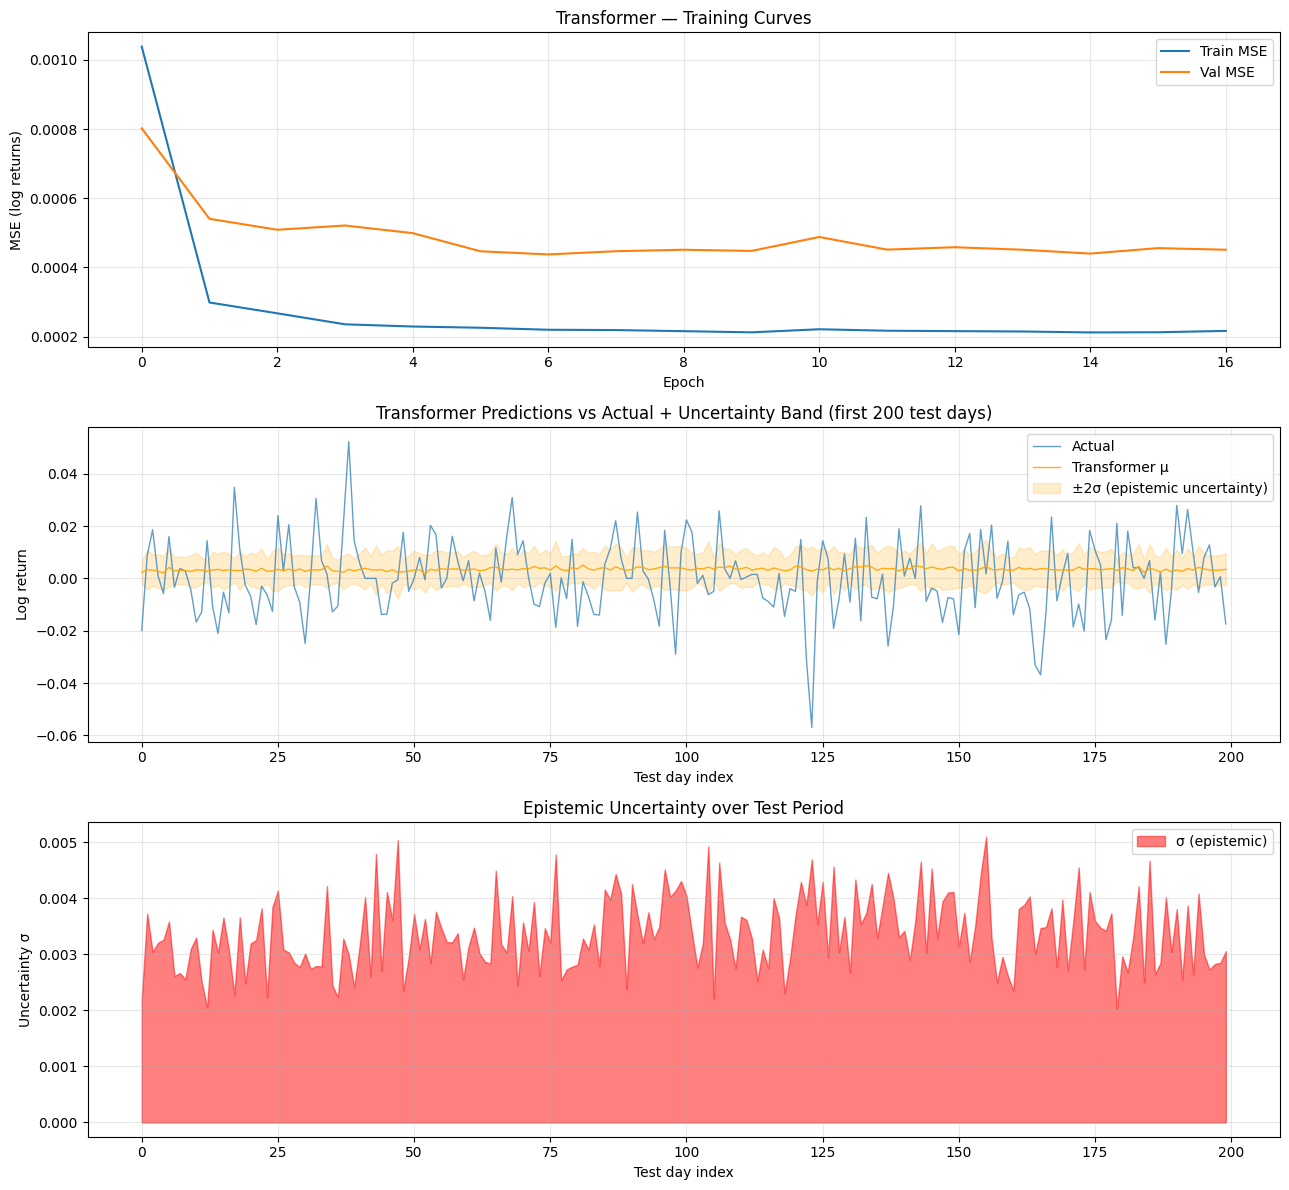

✅ Saved transformer_results_plot.png


In [14]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12))

# --- Plot 1: Training curves ---
axes[0].plot(history['train_loss'], label='Train MSE')
axes[0].plot(history['val_loss'],   label='Val MSE')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE (log returns)')
axes[0].set_title('Transformer — Training Curves')
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Plot 2: Predictions vs Actuals with uncertainty band ---
n_show = min(200, len(y_true_test))
x_idx  = np.arange(n_show)
mu_s   = mu_test[:n_show]
sig_s  = np.sqrt(sigma2_test[:n_show])

axes[1].plot(x_idx, y_true_test[:n_show], label='Actual',      alpha=0.7, linewidth=1)
axes[1].plot(x_idx, mu_s,                 label='Transformer μ', alpha=0.9, linewidth=1, color='orange')
axes[1].fill_between(
    x_idx,
    mu_s - 2 * sig_s,
    mu_s + 2 * sig_s,
    alpha=0.2, color='orange', label='±2σ (epistemic uncertainty)'
)
axes[1].set_xlabel('Test day index')
axes[1].set_ylabel('Log return')
axes[1].set_title(f'Transformer Predictions vs Actual + Uncertainty Band (first {n_show} test days)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- Plot 3: Epistemic uncertainty over time ---
axes[2].fill_between(x_idx, 0, sig_s, alpha=0.5, color='red', label='σ (epistemic)')
axes[2].set_xlabel('Test day index')
axes[2].set_ylabel('Uncertainty σ')
axes[2].set_title('Epistemic Uncertainty over Test Period')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('transformer_results_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved transformer_results_plot.png')

## Step 14: High-Uncertainty Days Analysis

Examine which test days have the highest epistemic uncertainty.
High-uncertainty periods often coincide with market turbulence.

In [15]:
# Attach dates to test predictions
test_dates = test_df.index[LOOKBACK - 1 :]  # align with windowed samples

uncertainty_df['date'] = test_dates[:len(uncertainty_df)].values
uncertainty_df = uncertainty_df.set_index('date')

top10 = uncertainty_df.nlargest(10, 'sigma2')[['y_true', 'mu_pred', 'sigma']]
top10.columns = ['Actual Return', 'Predicted μ', 'Uncertainty σ']
print('Top 10 highest-uncertainty test days:')
print(top10.round(5).to_string())

# Correlation between uncertainty and absolute error
abs_err = np.abs(uncertainty_df['y_true'] - uncertainty_df['mu_pred'])
corr = np.corrcoef(uncertainty_df['sigma'].values, abs_err.values)[0, 1]
print(f'\nCorrelation (σ vs |error|): {corr:.4f}')
print('(Positive = model is uncertain when it makes larger errors — good calibration)')

Top 10 highest-uncertainty test days:
            Actual Return  Predicted μ  Uncertainty σ
date                                                 
2025-01-22        0.00073      0.00329        0.00591
2026-01-23        0.01411      0.00408        0.00583
2026-04-02       -0.00887      0.00439        0.00583
2025-11-28        0.01979      0.00508        0.00529
2026-01-16        0.00625      0.00336        0.00527
2026-01-15        0.01686      0.00442        0.00516
2024-09-17        0.00168      0.00455        0.00510
2026-03-16        0.01994      0.00416        0.00505
2024-04-17       -0.00062      0.00229        0.00504
2025-10-20       -0.00164      0.00432        0.00503

Correlation (σ vs |error|): 0.0182
(Positive = model is uncertain when it makes larger errors — good calibration)
